# Análisis exploratorio

Esta notebook utiliza las tablas validadas por `01_auditoria_inicial_petshop.ipynb`.


## 1. Configuración y carga


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

DIRECTORIO_ACTUAL = Path.cwd().resolve()
RUTA_PROYECTO = (
    DIRECTORIO_ACTUAL.parent
    if DIRECTORIO_ACTUAL.name.lower() == "notebooks"
    else DIRECTORIO_ACTUAL
)
RUTA_PROCESADOS = RUTA_PROYECTO / "datos" / "procesados"

ARCHIVOS_REQUERIDOS = [
    "ventas_enriquecidas.csv",
    "stock_enriquecido.csv",
    "productos_dimension.csv",
    "clientes_dimension.csv",
]

faltantes = [
    nombre for nombre in ARCHIVOS_REQUERIDOS
    if not (RUTA_PROCESADOS / nombre).is_file()
]

if faltantes:
    raise FileNotFoundError(
        "Faltan archivos procesados: " + ", ".join(faltantes)
        + ". Ejecutá primero la notebook 01 completa."
    )

print("Directorio del proyecto:", RUTA_PROYECTO)
print("Directorio procesado:", RUTA_PROCESADOS)


Directorio del proyecto: /home/ips/Repositorio/Análisis de Datos/huellitas
Directorio procesado: /home/ips/Repositorio/Análisis de Datos/huellitas/datos/procesados


In [8]:
ventas = pd.read_csv(
    RUTA_PROCESADOS / "ventas_enriquecidas.csv",
    encoding="utf-8-sig",
    parse_dates=["fecha"],
    dtype={
        "id_venta": "string",
        "id_cliente": "string",
        "id_cliente_modelo": "string",
        "id_producto": "string",
    },
)

stock = pd.read_csv(
    RUTA_PROCESADOS / "stock_enriquecido.csv",
    encoding="utf-8-sig",
    parse_dates=["fecha"],
    dtype={"id_producto": "string"},
)

productos = pd.read_csv(
    RUTA_PROCESADOS / "productos_dimension.csv",
    encoding="utf-8-sig",
    dtype={"id_producto": "string"},
)

clientes = pd.read_csv(
    RUTA_PROCESADOS / "clientes_dimension.csv",
    encoding="utf-8-sig",
    parse_dates=["fecha_alta"],
    dtype={"id_cliente": "string"},
)

resumen_carga = pd.DataFrame([
    {"tabla": "ventas", "filas": len(ventas), "columnas": ventas.shape[1]},
    {"tabla": "stock", "filas": len(stock), "columnas": stock.shape[1]},
    {"tabla": "productos", "filas": len(productos), "columnas": productos.shape[1]},
    {"tabla": "clientes", "filas": len(clientes), "columnas": clientes.shape[1]},
])

display(resumen_carga)


,tabla,filas,columnas
0,ventas,19966,37
1,stock,585,20
2,productos,200,8
3,clientes,2002,6


## 2. Control de la base analítica


In [9]:
columnas_ventas_requeridas = {
    "id_linea_venta", "id_venta", "fecha", "id_producto", "cantidad",
    "precio_unitario", "descuento", "sucursal", "canal", "medio_pago",
    "producto", "categoria", "costo",
}

columnas_faltantes = columnas_ventas_requeridas.difference(ventas.columns)
assert not columnas_faltantes, f"Faltan columnas en ventas: {sorted(columnas_faltantes)}"
assert ventas["id_linea_venta"].is_unique
assert ventas["fecha"].notna().all()
assert ventas["cantidad"].gt(0).all()
assert ventas["precio_unitario"].gt(0).all()
assert ventas["descuento"].between(0, 1).all()

control_base = pd.Series({
    "fecha_desde": ventas["fecha"].min(),
    "fecha_hasta": ventas["fecha"].max(),
    "lineas_de_venta": len(ventas),
    "tickets": ventas["id_venta"].nunique(),
    "productos": ventas["id_producto"].nunique(),
    "clientes_modelados": ventas["id_cliente_modelo"].nunique(),
    "costos_faltantes": ventas["costo"].isna().sum(),
})

display(control_base.to_frame("valor"))
print("✓ La base analítica cumple los controles mínimos.")


,valor
fecha_desde,2025-01-01 00:00:00
fecha_hasta,2026-08-31 00:00:00
lineas_de_venta,19966
tickets,7967
productos,200
clientes_modelados,1933
costos_faltantes,481


✓ La base analítica cumple los controles mínimos.


### 2.1. Consistencia del nivel ticket

Algunas variables deberían tener un único valor dentro de cada `id_venta`: fecha, cliente, sucursal, canal y medio de pago. Este control evita atribuir un mismo ticket a más de un grupo sin advertirlo.


In [10]:
campos_nivel_ticket = ["fecha", "id_cliente_modelo", "sucursal", "canal", "medio_pago"]

consistencia_ticket = pd.DataFrame([
    {
        "campo": campo,
        "tickets_con_multiples_valores": (
            ventas.groupby("id_venta")[campo].nunique(dropna=False).gt(1).sum()
        ),
    }
    for campo in campos_nivel_ticket
])

display(consistencia_ticket)

campos_inconsistentes = consistencia_ticket.loc[
    consistencia_ticket["tickets_con_multiples_valores"].gt(0), "campo"
].tolist()

if campos_inconsistentes:
    print(
        "⚠ Hay atributos no uniformes dentro de algunos tickets: "
        + ", ".join(campos_inconsistentes)
    )
    print(
        "En los desgloses se informarán tickets involucrados, no tickets exclusivos. "
        "La facturación continúa calculándose correctamente a nivel línea."
    )
else:
    print("✓ Todos los atributos de ticket son uniformes dentro de cada venta.")


,campo,tickets_con_multiples_valores
0,fecha,4
1,id_cliente_modelo,12
2,sucursal,4
3,canal,0
4,medio_pago,5441


⚠ Hay atributos no uniformes dentro de algunos tickets: fecha, id_cliente_modelo, sucursal, medio_pago
En los desgloses se informarán tickets involucrados, no tickets exclusivos. La facturación continúa calculándose correctamente a nivel línea.


## 3. Construcción y validación de métricas

Cada fila representa una línea de producto dentro de una venta. Por eso el ticket promedio usa ventas únicas (`id_venta`), no cantidad de filas.

Los costos faltantes permanecen como `NaN`. No se reemplazan por cero porque eso inflaría artificialmente el margen.


In [11]:
ventas_analiticas = ventas.copy()

ventas_analiticas["venta_bruta"] = (
    ventas_analiticas["cantidad"] * ventas_analiticas["precio_unitario"]
)
ventas_analiticas["descuento_aplicado"] = (
    ventas_analiticas["venta_bruta"] * ventas_analiticas["descuento"]
)
ventas_analiticas["facturacion_neta"] = (
    ventas_analiticas["venta_bruta"]
    - ventas_analiticas["descuento_aplicado"]
)
ventas_analiticas["costo_total"] = (
    ventas_analiticas["cantidad"] * ventas_analiticas["costo"]
)
ventas_analiticas["margen"] = (
    ventas_analiticas["facturacion_neta"]
    - ventas_analiticas["costo_total"]
)
ventas_analiticas["margen_porcentaje"] = np.where(
    ventas_analiticas["facturacion_neta"].ne(0)
    & ventas_analiticas["margen"].notna(),
    ventas_analiticas["margen"] / ventas_analiticas["facturacion_neta"],
    np.nan,
)

ventas_analiticas["mes"] = ventas_analiticas["fecha"].dt.to_period("M").dt.to_timestamp()
ventas_analiticas["dia_semana_numero"] = ventas_analiticas["fecha"].dt.dayofweek
mapa_dias = {
    0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves",
    4: "Viernes", 5: "Sábado", 6: "Domingo",
}
ventas_analiticas["dia_semana"] = ventas_analiticas["dia_semana_numero"].map(mapa_dias)

assert np.allclose(
    ventas_analiticas["facturacion_neta"],
    ventas_analiticas["cantidad"]
    * ventas_analiticas["precio_unitario"]
    * (1 - ventas_analiticas["descuento"]),
)
assert ventas_analiticas.loc[
    ventas_analiticas["costo"].isna(), "margen"
].isna().all()

print("✓ Métricas calculadas y validadas.")


✓ Métricas calculadas y validadas.


## 4. KPIs generales


In [12]:
facturacion_total = ventas_analiticas["facturacion_neta"].sum()
ventas_unicas = ventas_analiticas["id_venta"].nunique()
unidades_vendidas = ventas_analiticas["cantidad"].sum()
ticket_promedio = facturacion_total / ventas_unicas
descuentos_totales = ventas_analiticas["descuento_aplicado"].sum()

filas_con_costo = ventas_analiticas["costo_total"].notna()
facturacion_con_costo = ventas_analiticas.loc[filas_con_costo, "facturacion_neta"].sum()
costo_conocido = ventas_analiticas.loc[filas_con_costo, "costo_total"].sum()
margen_conocido = ventas_analiticas.loc[filas_con_costo, "margen"].sum()
margen_porcentaje_conocido = margen_conocido / facturacion_con_costo
cobertura_costos = facturacion_con_costo / facturacion_total

kpis = pd.DataFrame({
    "indicador": [
        "Facturación neta", "Tickets", "Unidades vendidas",
        "Ticket promedio", "Descuentos aplicados", "Costo conocido",
        "Margen sobre ventas con costo", "Margen % sobre ventas con costo",
        "Cobertura de costos sobre facturación",
    ],
    "valor": [
        facturacion_total, ventas_unicas, unidades_vendidas,
        ticket_promedio, descuentos_totales, costo_conocido,
        margen_conocido, margen_porcentaje_conocido, cobertura_costos,
    ],
})

display(kpis)
print(
    "Nota: margen y margen % sólo consideran líneas con costo disponible. "
    f"Cobertura: {cobertura_costos:.1%}."
)


,indicador,valor
0,Facturación neta,"797,723,435.00"
1,Tickets,"7,967.00"
2,Unidades vendidas,"28,740.00"
3,Ticket promedio,"100,128.46"
4,Descuentos aplicados,"30,650,085.00"
5,Costo conocido,"528,601,709.00"
6,Margen sobre ventas con costo,"243,700,585.50"
7,Margen % sobre ventas con costo,0.32
8,Cobertura de costos sobre facturación,0.97


Nota: margen y margen % sólo consideran líneas con costo disponible. Cobertura: 96.8%.


## 5. Evolución mensual


,mes,facturacion,tickets,unidades,clientes,ticket_promedio,variacion_mensual
0,2025-01-01,"41,234,991.00",401,1473,327,"102,830.40",NaN
1,2025-02-01,"37,808,683.50",381,1340,304,"99,235.39",-0.08
2,2025-03-01,"38,656,443.50",396,1385,315,"97,617.28",0.02
3,2025-04-01,"42,224,239.00",406,1497,331,"104,000.59",0.09
4,2025-05-01,"39,185,323.00",410,1469,324,"95,573.96",-0.07
5,2025-06-01,"38,562,140.00",367,1332,303,"105,073.95",-0.02
6,2025-07-01,"41,144,437.50",415,1502,334,"99,143.22",0.07
7,2025-08-01,"40,250,046.00",396,1421,311,"101,641.53",-0.02
8,2025-09-01,"38,295,270.50",394,1323,320,"97,196.12",-0.05
9,2025-10-01,"42,151,886.50",405,1545,324,"104,078.73",0.10


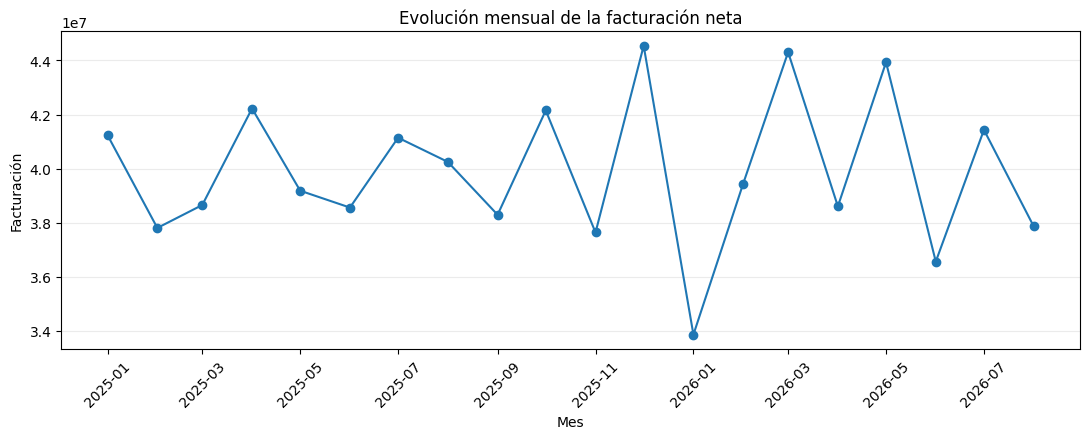

In [13]:
ventas_mensuales = (
    ventas_analiticas
    .groupby("mes", as_index=False)
    .agg(
        facturacion=("facturacion_neta", "sum"),
        tickets=("id_venta", "nunique"),
        unidades=("cantidad", "sum"),
        clientes=("id_cliente_modelo", "nunique"),
    )
    .sort_values("mes")
)
ventas_mensuales["ticket_promedio"] = (
    ventas_mensuales["facturacion"] / ventas_mensuales["tickets"]
)
ventas_mensuales["variacion_mensual"] = ventas_mensuales["facturacion"].pct_change()

display(ventas_mensuales)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ventas_mensuales["mes"], ventas_mensuales["facturacion"], marker="o")
ax.set(title="Evolución mensual de la facturación neta", xlabel="Mes", ylabel="Facturación")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Sucursales y canales


,sucursal,facturacion,tickets_involucrados,unidades,margen_conocido,facturacion_por_ticket_involucrado,participacion
0,Centro,"283,111,836.50",2805,10272,"87,156,975.00","100,931.14",0.35
2,Ecommerce,"195,335,090.00",1941,6944,"59,124,068.50","100,636.32",0.24
1,City Bell,"184,853,587.50",1888,6771,"56,587,110.00","97,909.74",0.23
3,Los Hornos,"134,422,921.00",1337,4753,"40,832,432.00","100,540.70",0.17


,canal,facturacion,tickets_involucrados,unidades,margen_conocido,facturacion_por_ticket_involucrado,participacion
0,Local,"602,322,425.00",6026,21794,"184,558,797.00","99,953.94",0.76
1,Online,"195,401,010.00",1941,6946,"59,141,788.50","100,670.28",0.24


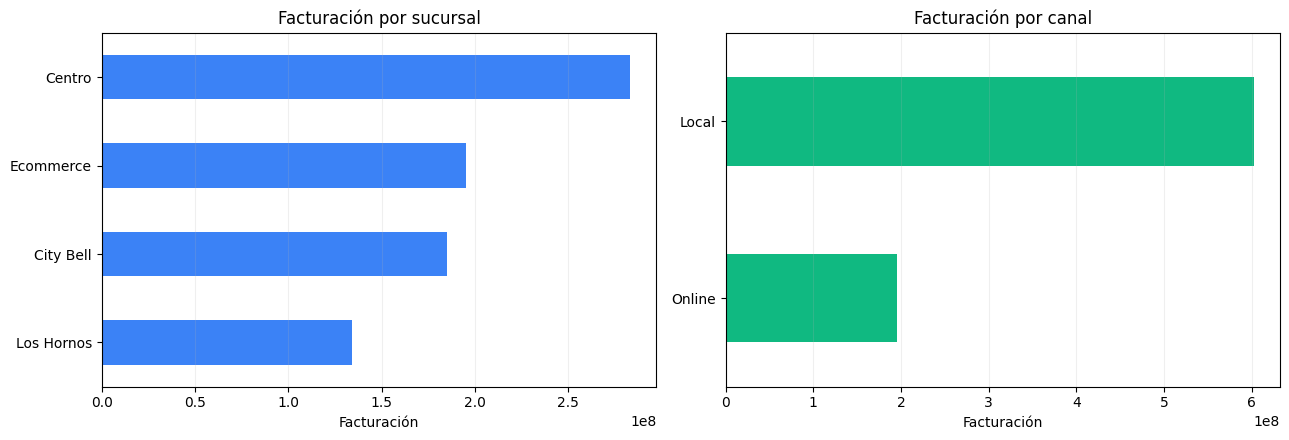

In [14]:
def resumir_dimension(datos, dimension):
    resumen = (
        datos.groupby(dimension, as_index=False)
        .agg(
            facturacion=("facturacion_neta", "sum"),
            tickets_involucrados=("id_venta", "nunique"),
            unidades=("cantidad", "sum"),
            margen_conocido=("margen", "sum"),
        )
    )
    resumen["facturacion_por_ticket_involucrado"] = (
        resumen["facturacion"] / resumen["tickets_involucrados"]
    )
    resumen["participacion"] = resumen["facturacion"] / resumen["facturacion"].sum()
    return resumen.sort_values("facturacion", ascending=False)


ventas_por_sucursal = resumir_dimension(ventas_analiticas, "sucursal")
ventas_por_canal = resumir_dimension(ventas_analiticas, "canal")

display(ventas_por_sucursal)
display(ventas_por_canal)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ventas_por_sucursal.sort_values("facturacion").plot.barh(
    x="sucursal", y="facturacion", ax=axes[0], legend=False, color="#3b82f6"
)
ventas_por_canal.sort_values("facturacion").plot.barh(
    x="canal", y="facturacion", ax=axes[1], legend=False, color="#10b981"
)
axes[0].set_title("Facturación por sucursal")
axes[1].set_title("Facturación por canal")
for ax in axes:
    ax.set_xlabel("Facturación")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


## 7. Categorías y productos


,categoria,facturacion,tickets_involucrados,unidades,margen_conocido,facturacion_por_ticket_involucrado,participacion
1,Alimentos,"528,315,715.50",6610,16795,"159,510,321.50","79,926.73",0.66
0,Accesorios,"167,825,079.50",2356,3762,"53,809,547.00","71,233.06",0.21
3,Salud,"48,899,999.00",1436,2245,"14,502,563.50","34,052.92",0.06
2,Higiene,"36,220,450.00",2045,3306,"10,156,962.50","17,711.71",0.05
4,Snacks,"16,462,191.00",1739,2632,"5,721,191.00","9,466.47",0.02


,id_producto,producto,categoria,facturacion,unidades,tickets,margen_conocido,lineas_sin_costo
0,P0001,Pedigree Cachorro Perro 3 kg,Alimentos,"28,030,880.50",1219,863,"9,380,180.50",0
5,P0006,Pedigree Premium Gato 3 kg,Alimentos,"21,060,332.00",434,297,"7,953,532.00",0
12,P0013,Excellent Cachorro Perro 10 kg,Alimentos,"15,275,751.00",281,181,0.00,181
15,P0016,Pedigree Cachorro Gato 3 kg,Alimentos,"14,989,338.50",228,158,"2,973,738.50",0
7,P0008,Excellent Piel sensible Gato 10 kg,Alimentos,"13,973,013.00",316,210,"4,177,013.00",0
20,P0021,Pedigree Premium Perro 3 kg,Alimentos,"12,366,770.50",259,171,"5,037,070.50",0
13,P0014,Balanced Piel sensible Gato 15 kg,Alimentos,"11,725,407.50",261,173,"3,373,407.50",0
2,P0003,Excellent Premium Perro 10 kg,Alimentos,"11,724,353.00",481,332,"5,086,553.00",0
38,P0039,Balanced Premium Perro 15 kg,Alimentos,"11,426,196.00",181,121,"4,077,596.00",0
19,P0020,Catit Piel sensible Gato 1 kg,Alimentos,"10,757,911.00",230,158,"2,201,911.00",0


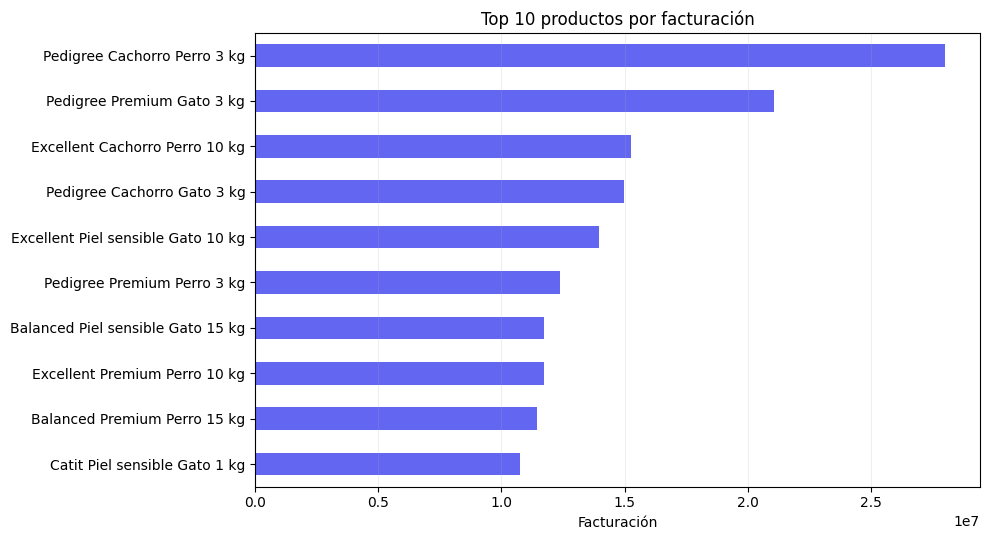

In [15]:
ventas_por_categoria = resumir_dimension(ventas_analiticas, "categoria")

ventas_por_producto = (
    ventas_analiticas
    .groupby(["id_producto", "producto", "categoria"], as_index=False)
    .agg(
        facturacion=("facturacion_neta", "sum"),
        unidades=("cantidad", "sum"),
        tickets=("id_venta", "nunique"),
        margen_conocido=("margen", "sum"),
        lineas_sin_costo=("costo", lambda serie: serie.isna().sum()),
    )
    .sort_values("facturacion", ascending=False)
)

display(ventas_por_categoria)
display(ventas_por_producto.head(10))

top_productos = ventas_por_producto.head(10).sort_values("facturacion")
ax = top_productos.plot.barh(
    x="producto", y="facturacion", figsize=(10, 5.5),
    legend=False, color="#6366f1",
)
ax.set(title="Top 10 productos por facturación", xlabel="Facturación", ylabel="")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


## 8. Clientes


In [16]:
ventas_clientes_registrados = ventas_analiticas[
    ~ventas_analiticas["id_cliente_modelo"].isin(["C_INVITADO", "C_NO_ENCONTRADO"])
].copy()

clientes_resumen = (
    ventas_clientes_registrados
    .groupby(["id_cliente_modelo", "nombre", "ciudad", "mascota"], dropna=False, as_index=False)
    .agg(
        facturacion=("facturacion_neta", "sum"),
        tickets=("id_venta", "nunique"),
        unidades=("cantidad", "sum"),
        primera_compra=("fecha", "min"),
        ultima_compra=("fecha", "max"),
    )
)
clientes_resumen["ticket_promedio"] = clientes_resumen["facturacion"] / clientes_resumen["tickets"]
clientes_resumen["dias_desde_ultima_compra"] = (
    ventas_analiticas["fecha"].max() - clientes_resumen["ultima_compra"]
).dt.days
clientes_resumen.sort_values("facturacion", ascending=False, inplace=True)

participacion_clientes_identificados = (
    ventas_clientes_registrados["facturacion_neta"].sum()
    / ventas_analiticas["facturacion_neta"].sum()
)

print(f"Facturación asociada a clientes identificados: {participacion_clientes_identificados:.1%}")
display(clientes_resumen.head(10))


Facturación asociada a clientes identificados: 86.4%


,id_cliente_modelo,nombre,ciudad,mascota,facturacion,tickets,unidades,primera_compra,ultima_compra,ticket_promedio,dias_desde_ultima_compra
280,C0291,Bruno Sánchez,Los Hornos,Perro,"1,521,602.00",8,35,2025-03-07,2026-03-28,"190,200.25",156
1490,C1541,Nicolás Gómez,Villa Elisa,Perro y gato,"1,352,064.50",9,42,2025-04-14,2026-07-26,"150,229.39",36
1769,C1834,Facundo Ruiz,City Bell,Perro,"1,336,268.50",8,42,2025-01-06,2026-06-12,"167,033.56",80
545,C0562,Bruno López,Ensenada,Gato,"1,279,591.00",9,41,2025-01-26,2026-08-21,"142,176.78",10
1405,C1453,Delfina Silva,Berisso,Gato,"1,227,010.00",7,45,2025-12-30,2026-08-19,"175,287.14",12
1719,C1782,Franco Sánchez,La Plata,Gato,"1,206,812.00",6,26,2025-09-11,2026-04-06,"201,135.33",147
1132,C1169,Julieta Ruiz,City Bell,Gato,"1,175,125.00",9,30,2025-01-17,2026-05-28,"130,569.44",95
1016,C1051,Martina Romero,La Plata,Gato,"1,164,341.50",9,41,2025-04-12,2026-06-18,"129,371.28",74
1085,C1121,Bruno Benítez,Los Hornos,Gato,"1,154,042.50",8,34,2025-01-08,2026-06-16,"144,255.31",76
1663,C1723,Santiago López,Ringuelet,Perro,"1,135,284.00",7,35,2025-01-01,2026-05-27,"162,183.43",96


## 9. Stock


In [17]:
stock_analitico = stock.copy()
stock_analitico["brecha_stock"] = (
    stock_analitico["stock_actual"] - stock_analitico["stock_minimo"]
)
stock_analitico["estado_stock"] = np.select(
    [
        stock_analitico["stock_actual"].eq(0),
        stock_analitico["stock_actual"].le(stock_analitico["stock_minimo"]),
    ],
    ["Sin stock", "Bajo mínimo"],
    default="Disponible",
)

resumen_stock = (
    stock_analitico.groupby(["sucursal", "estado_stock"], as_index=False)
    .agg(productos=("id_producto", "nunique"))
)

alertas_stock = (
    stock_analitico[stock_analitico["estado_stock"] != "Disponible"]
    .sort_values(["estado_stock", "brecha_stock"])
    [["fecha", "sucursal", "id_producto", "producto", "categoria",
      "stock_actual", "stock_minimo", "brecha_stock", "estado_stock"]]
)

display(resumen_stock)
display(alertas_stock.head(20))


,sucursal,estado_stock,productos
0,Centro,Bajo mínimo,57
1,Centro,Disponible,124
2,Centro,Sin stock,14
3,City Bell,Bajo mínimo,57
4,City Bell,Disponible,127
5,City Bell,Sin stock,11
6,Los Hornos,Bajo mínimo,43
7,Los Hornos,Disponible,136
8,Los Hornos,Sin stock,16


,fecha,sucursal,id_producto,producto,categoria,stock_actual,stock_minimo,brecha_stock,estado_stock
2,2026-08-31,Centro,P0003,Excellent Premium Perro 10 kg,Alimentos,3,7.00,-4.00,Bajo mínimo
16,2026-08-31,Centro,P0017,"König Piel sensible Perro 7,5 kg",Alimentos,1,3.00,-2.00,Bajo mínimo
13,2026-08-31,Centro,P0014,Balanced Piel sensible Gato 15 kg,Alimentos,2,3.00,-1.00,Bajo mínimo
19,2026-08-31,Centro,P0020,Catit Piel sensible Gato 1 kg,Alimentos,2,3.00,-1.00,Bajo mínimo
23,2026-08-31,Centro,P0024,Balanced Premium Gato 15 kg,Alimentos,2,3.00,-1.00,Bajo mínimo
25,2026-08-31,Centro,P0026,Pedigree Piel sensible Gato 3 kg,Alimentos,1,2.00,-1.00,Bajo mínimo
33,2026-08-31,Centro,P0035,Catit Piel sensible Perro 1 kg,Alimentos,2,3.00,-1.00,Bajo mínimo
40,2026-08-31,Centro,P0042,"König Premium Gato 7,5 kg",Alimentos,1,2.00,-1.00,Bajo mínimo
49,2026-08-31,Centro,P0051,Pedigree Premium Perro 3 kg,Alimentos,1,2.00,-1.00,Bajo mínimo
51,2026-08-31,Centro,P0053,Excellent Piel sensible Perro 10 kg,Alimentos,1,2.00,-1.00,Bajo mínimo


## 10. Día de la semana y medios de pago


,dia_semana,facturacion,tickets,ticket_promedio
0,Lunes,"111,481,561.00",1080,"103,223.67"
1,Martes,"112,115,621.50",1150,"97,491.84"
2,Miércoles,"107,788,475.00",1124,"95,897.22"
3,Jueves,"120,405,361.00",1155,"104,247.07"
4,Viernes,"116,537,823.00",1138,"102,405.82"
5,Sábado,"116,440,444.00",1155,"100,814.24"
6,Domingo,"112,954,149.50",1168,"96,707.32"


,medio_pago,facturacion,tickets_involucrados,unidades,margen_conocido,facturacion_por_ticket_involucrado,participacion
1,Débito,"173,823,433.00",3407,6184,"53,480,851.00","51,019.50",0.22
0,Crédito,"169,216,311.50",3415,6055,"51,763,295.50","49,550.90",0.21
5,Transferencia,"165,485,346.00",3362,5904,"50,381,578.00","49,222.29",0.21
2,Efectivo,"121,217,584.50",2532,4435,"37,238,682.50","47,874.24",0.15
4,QR,"121,084,452.00",2493,4405,"36,708,936.50","48,569.78",0.15
3,Mercado Pago,"46,896,308.00",944,1757,"14,127,242.00","49,678.29",0.06


Nota: un id_venta puede contener más de un medio de pago en la fuente. Por eso se muestran tickets involucrados y no una distribución exclusiva de tickets.


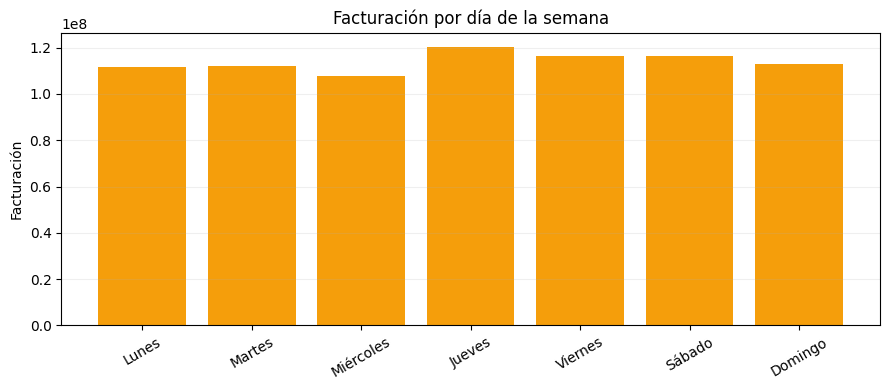

In [18]:
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

ventas_por_dia = (
    ventas_analiticas.groupby(["dia_semana_numero", "dia_semana"], as_index=False)
    .agg(facturacion=("facturacion_neta", "sum"), tickets=("id_venta", "nunique"))
    .sort_values("dia_semana_numero")
)
ventas_por_dia["ticket_promedio"] = ventas_por_dia["facturacion"] / ventas_por_dia["tickets"]

ventas_por_pago = resumir_dimension(ventas_analiticas, "medio_pago")

display(ventas_por_dia.drop(columns="dia_semana_numero"))
display(ventas_por_pago)
print(
    "Nota: un id_venta puede contener más de un medio de pago en la fuente. "
    "Por eso se muestran tickets involucrados y no una distribución exclusiva de tickets."
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ventas_por_dia["dia_semana"], ventas_por_dia["facturacion"], color="#f59e0b")
ax.set(title="Facturación por día de la semana", xlabel="", ylabel="Facturación")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Análisis de Pareto

89 productos (44.5% del catálogo) generan aproximadamente el 80 % de la facturación.


,id_producto,producto,categoria,facturacion,participacion_acumulada
0,P0001,Pedigree Cachorro Perro 3 kg,Alimentos,"28,030,880.50",0.04
1,P0006,Pedigree Premium Gato 3 kg,Alimentos,"21,060,332.00",0.06
2,P0013,Excellent Cachorro Perro 10 kg,Alimentos,"15,275,751.00",0.08
3,P0016,Pedigree Cachorro Gato 3 kg,Alimentos,"14,989,338.50",0.10
4,P0008,Excellent Piel sensible Gato 10 kg,Alimentos,"13,973,013.00",0.12
5,P0021,Pedigree Premium Perro 3 kg,Alimentos,"12,366,770.50",0.13
6,P0014,Balanced Piel sensible Gato 15 kg,Alimentos,"11,725,407.50",0.15
7,P0003,Excellent Premium Perro 10 kg,Alimentos,"11,724,353.00",0.16
8,P0039,Balanced Premium Perro 15 kg,Alimentos,"11,426,196.00",0.18
9,P0020,Catit Piel sensible Gato 1 kg,Alimentos,"10,757,911.00",0.19


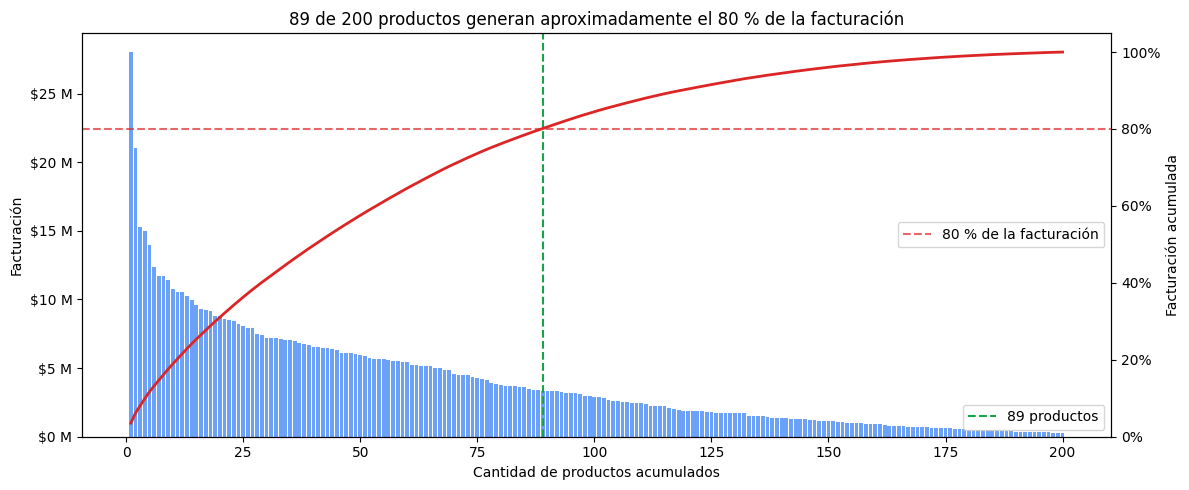

In [19]:
# Análisis de Pareto: productos que generan el 80 % de la facturación

pareto_productos = (
    ventas_por_producto
    .sort_values("facturacion", ascending=False)
    .reset_index(drop=True)
    .copy()
)

pareto_productos["facturacion_acumulada"] = (
    pareto_productos["facturacion"].cumsum()
)

pareto_productos["participacion_acumulada"] = (
    pareto_productos["facturacion_acumulada"]
    / pareto_productos["facturacion"].sum()
)

cantidad_productos_80 = (
    pareto_productos["participacion_acumulada"]
    .searchsorted(0.80)
    + 1
)

porcentaje_productos_80 = (
    cantidad_productos_80
    / len(pareto_productos)
)

print(
    f"{cantidad_productos_80} productos "
    f"({porcentaje_productos_80:.1%} del catálogo) "
    "generan aproximadamente el 80 % de la facturación."
)

display(
    pareto_productos.head(cantidad_productos_80)[
        [
            "id_producto",
            "producto",
            "categoria",
            "facturacion",
            "participacion_acumulada"
        ]
    ]
)

# Grafico
from matplotlib.ticker import PercentFormatter, FuncFormatter

fig, ax1 = plt.subplots(figsize=(12, 5))

posiciones = pareto_productos.index + 1

ax1.bar(
    posiciones,
    pareto_productos["facturacion"],
    color="#3b82f6",
    alpha=0.75
)

ax1.axvline(
    cantidad_productos_80,
    color="#16a34a",
    linestyle="--",
    label=f"{cantidad_productos_80} productos"
)

ax1.set_xlabel("Cantidad de productos acumulados")
ax1.set_ylabel("Facturación")
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"${valor / 1_000_000:.0f} M")
)

ax2 = ax1.twinx()

ax2.plot(
    posiciones,
    pareto_productos["participacion_acumulada"],
    color="#dc2626",
    linewidth=2
)

ax2.axhline(
    0.80,
    color="#dc2626",
    linestyle="--",
    alpha=0.7,
    label="80 % de la facturación"
)

ax2.set_ylabel("Facturación acumulada")
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.set_ylim(0, 1.05)

ax1.set_title(
    "89 de 200 productos generan aproximadamente el 80 % de la facturación"
)

ax1.legend(loc="lower right")
ax2.legend(loc="center right")

plt.tight_layout()
plt.show()

## 11. Exportación de resultados del análisis


In [21]:
RUTA_RESULTADOS = RUTA_PROYECTO / "datos" / "resultados"
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

resultados_para_exportar = {
    "kpis_generales.csv": kpis,
    "ventas_mensuales.csv": ventas_mensuales,
    "ventas_por_sucursal.csv": ventas_por_sucursal,
    "ventas_por_canal.csv": ventas_por_canal,
    "ventas_por_categoria.csv": ventas_por_categoria,
    "ventas_por_producto.csv": ventas_por_producto,
    "clientes_resumen.csv": clientes_resumen,
    "alertas_stock.csv": alertas_stock,
}

for nombre_archivo, tabla in resultados_para_exportar.items():
    tabla.to_csv(RUTA_RESULTADOS / nombre_archivo, index=False, encoding="utf-8-sig")

print(f"✓ {len(resultados_para_exportar)} resultados exportados en: {RUTA_RESULTADOS}")


✓ 8 resultados exportados en: /home/ips/Repositorio/Análisis de Datos/huellitas/datos/resultados


## Comparación anual

In [28]:
anios_disponibles = sorted(
    ventas_analiticas["fecha"].dt.year.unique()
)

anio_base = anios_disponibles[-2]
anio_actual = anios_disponibles[-1]

ultimo_mes_actual = (
    ventas_analiticas.loc[
        ventas_analiticas["fecha"].dt.year.eq(anio_actual),
        "fecha"
    ]
    .dt.month
    .max()
)

ventas_comparables = ventas_analiticas[
    ventas_analiticas["fecha"].dt.year.isin(
        [anio_base, anio_actual]
    )
    & ventas_analiticas["fecha"].dt.month.le(
        ultimo_mes_actual
    )
].copy()

ventas_comparables["anio"] = (
    ventas_comparables["fecha"].dt.year
)

print(
    f"Comparación: enero a mes {ultimo_mes_actual} "
    f"de {anio_base} contra {anio_actual}"
)

Comparación: enero a mes 8 de 2025 contra 2026


In [29]:
def comparar_dimension(datos, dimension):
    resumen = (
        datos
        .groupby([dimension, "anio"], as_index=False)
        .agg(
            facturacion=("facturacion_neta", "sum"),
            unidades=("cantidad", "sum"),
            tickets_involucrados=("id_venta", "nunique")
        )
    )

    periodo_base = (
        resumen[resumen["anio"].eq(anio_base)]
        .drop(columns="anio")
        .rename(
            columns={
                "facturacion": f"facturacion_{anio_base}",
                "unidades": f"unidades_{anio_base}",
                "tickets_involucrados": f"tickets_{anio_base}"
            }
        )
    )

    periodo_actual = (
        resumen[resumen["anio"].eq(anio_actual)]
        .drop(columns="anio")
        .rename(
            columns={
                "facturacion": f"facturacion_{anio_actual}",
                "unidades": f"unidades_{anio_actual}",
                "tickets_involucrados": f"tickets_{anio_actual}"
            }
        )
    )

    comparacion = periodo_base.merge(
        periodo_actual,
        on=dimension,
        how="outer"
    ).fillna(0)

    comparacion["variacion_facturacion_absoluta"] = (
        comparacion[f"facturacion_{anio_actual}"]
        - comparacion[f"facturacion_{anio_base}"]
    )

    comparacion["variacion_facturacion_porcentaje"] = np.where(
        comparacion[f"facturacion_{anio_base}"].ne(0),
        comparacion["variacion_facturacion_absoluta"]
        / comparacion[f"facturacion_{anio_base}"],
        np.nan
    )

    comparacion["variacion_unidades_porcentaje"] = np.where(
        comparacion[f"unidades_{anio_base}"].ne(0),
        (
            comparacion[f"unidades_{anio_actual}"]
            - comparacion[f"unidades_{anio_base}"]
        )
        / comparacion[f"unidades_{anio_base}"],
        np.nan
    )

    return comparacion.sort_values(
        "variacion_facturacion_absoluta"
    )

In [30]:
comparacion_sucursales = comparar_dimension(
    ventas_comparables,
    "sucursal"
)

display(comparacion_sucursales)

,sucursal,facturacion_2025,unidades_2025,tickets_2025,facturacion_2026,unidades_2026,tickets_2026,variacion_facturacion_absoluta,variacion_facturacion_porcentaje,variacion_unidades_porcentaje
0,Centro,"113,104,915.00",4126,1132,"108,993,301.00",4036,1089,"-4,111,614.00",-0.04,-0.02
1,City Bell,"75,783,698.50",2716,748,"72,913,916.00",2686,756,"-2,869,782.50",-0.04,-0.01
3,Los Hornos,"54,531,339.50",1921,536,"52,608,255.50",1866,536,"-1,923,084.00",-0.04,-0.03
2,Ecommerce,"75,646,350.50",2656,758,"81,510,911.50",2892,807,"5,864,561.00",0.08,0.09


In [31]:
display(
    comparacion_sucursales.style.format(
        {
            f"facturacion_{anio_base}": "${:,.0f}",
            f"facturacion_{anio_actual}": "${:,.0f}",
            "variacion_facturacion_absoluta": "${:,.0f}",
            "variacion_facturacion_porcentaje": "{:.1%}",
            "variacion_unidades_porcentaje": "{:.1%}"
        }
    )
)

,sucursal,facturacion_2025,unidades_2025,tickets_2025,facturacion_2026,unidades_2026,tickets_2026,variacion_facturacion_absoluta,variacion_facturacion_porcentaje,variacion_unidades_porcentaje
0,Centro,"$113,104,915",4126,1132,"$108,993,301",4036,1089,"$-4,111,614",-3.6%,-2.2%
1,City Bell,"$75,783,698",2716,748,"$72,913,916",2686,756,"$-2,869,782",-3.8%,-1.1%
3,Los Hornos,"$54,531,340",1921,536,"$52,608,256",1866,536,"$-1,923,084",-3.5%,-2.9%
2,Ecommerce,"$75,646,350",2656,758,"$81,510,912",2892,807,"$5,864,561",7.8%,8.9%


In [32]:
comparacion_categorias = comparar_dimension(
    ventas_comparables,
    "categoria"
)

display(
    comparacion_categorias.style.format(
        {
            f"facturacion_{anio_base}": "${:,.0f}",
            f"facturacion_{anio_actual}": "${:,.0f}",
            "variacion_facturacion_absoluta": "${:,.0f}",
            "variacion_facturacion_porcentaje": "{:.1%}",
            "variacion_unidades_porcentaje": "{:.1%}"
        }
    )
)

,categoria,facturacion_2025,unidades_2025,tickets_2025,facturacion_2026,unidades_2026,tickets_2026,variacion_facturacion_absoluta,variacion_facturacion_porcentaje,variacion_unidades_porcentaje
1,Alimentos,"$211,226,770",6653,2613,"$207,716,102",6667,2658,"$-3,510,668",-1.7%,0.2%
3,Salud,"$19,913,962",899,578,"$18,750,854",889,568,"$-1,163,109",-5.8%,-1.1%
4,Snacks,"$6,833,138",1094,720,"$6,627,862",1054,686,"$-205,276",-3.0%,-3.7%
2,Higiene,"$14,500,827",1295,801,"$14,481,899",1316,826,"$-18,928",-0.1%,1.6%
0,Accesorios,"$66,591,606",1478,926,"$68,449,668",1554,973,"$1,858,062",2.8%,5.1%


In [33]:
def graficar_variacion(tabla, dimension, titulo):
    tabla_grafico = tabla.sort_values(
        "variacion_facturacion_absoluta"
    )

    colores = np.where(
        tabla_grafico["variacion_facturacion_absoluta"].ge(0),
        "#16a34a",
        "#dc2626"
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.barh(
        tabla_grafico[dimension],
        tabla_grafico["variacion_facturacion_absoluta"],
        color=colores
    )

    ax.axvline(0, color="black", linewidth=0.8)

    ax.set_title(titulo)
    ax.set_xlabel(
        f"Diferencia de facturación: {anio_actual} frente a {anio_base}"
    )
    ax.set_ylabel("")

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            lambda valor, _: f"${valor / 1_000_000:.1f} M"
        )
    )

    ax.grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

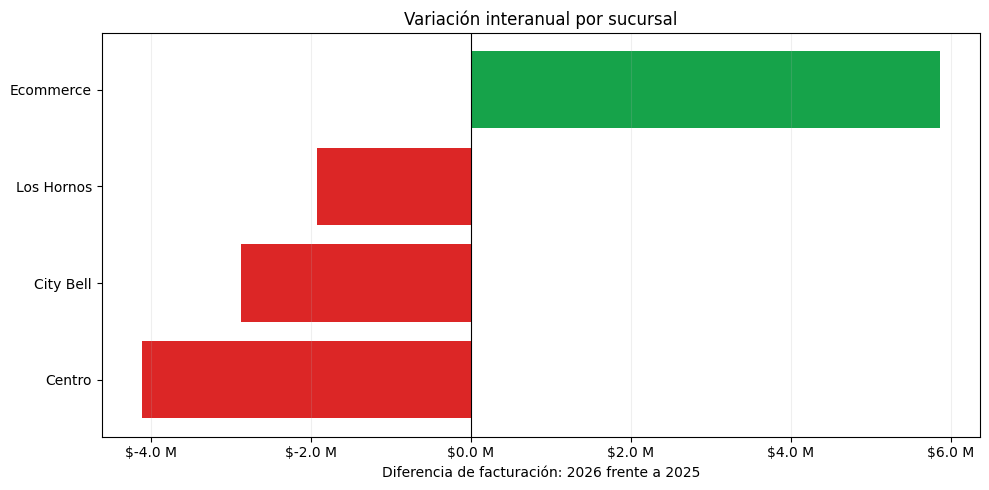

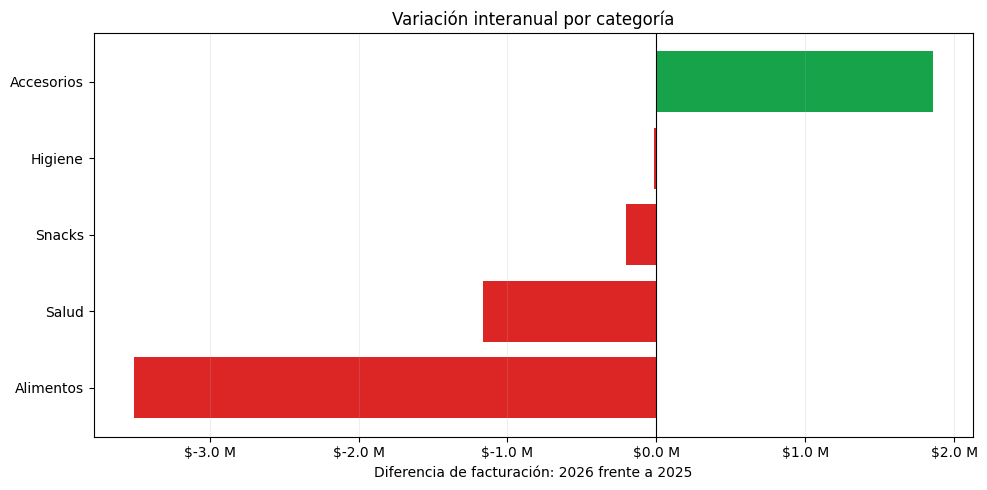

In [34]:
graficar_variacion(
    comparacion_sucursales,
    "sucursal",
    "Variación interanual por sucursal"
)

graficar_variacion(
    comparacion_categorias,
    "categoria",
    "Variación interanual por categoría"
)

In [35]:
comparacion_sucursales.to_csv(
    RUTA_RESULTADOS / "comparacion_interanual_sucursales.csv",
    index=False,
    encoding="utf-8-sig"
)

comparacion_categorias.to_csv(
    RUTA_RESULTADOS / "comparacion_interanual_categorias.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✓ Comparaciones interanuales exportadas.")

✓ Comparaciones interanuales exportadas.


## Conclusiones ejecutivas

### Situación general

Entre enero y agosto de 2026, la facturación presentó una variación de aproximadamente -0,94 % frente al mismo periodo de 2025. Esto indica una situación estable, aunque sin crecimiento real.

### Principales hallazgos

1. Una sucursal perdió facturación frente al periodo comparable de 2025, mientras el resultado total se mantuvo prácticamente estable.
2. Alimentos concentra aproximadamente el 66 % de la facturación, por lo que es la categoría más relevante para el desempeño comercial.
3. 89 de los 200 productos explican aproximadamente el 80 % de la facturación.
4. Se detectaron productos con cobertura insuficiente: 39 combinaciones producto-sucursal están en quiebre con demanda y 3 tienen hasta 7 días de cobertura.
5. La calidad de algunos datos limita el análisis económico: hay costos faltantes en ventas y el medio de pago es inconsistente dentro de numerosos tickets.

### Recomendaciones

1. Revisar en la sucursal que perdió facturación el volumen vendido, la cantidad de clientes y el desempeño por categoría para definir acciones comerciales específicas.
2. Asegurar la disponibilidad de Alimentos y negociar condiciones con proveedores para proteger la categoría que concentra la mayor parte de la facturación.
3. Priorizar los 89 productos principales en compras, reposición y seguimiento de ventas.
4. Generar una lista priorizada de reposición para los productos sin stock o con pocos días de cobertura, considerando la demanda reciente por sucursal.
5. Completar el maestro de costos antes de evaluar el margen total y corregir el proceso de captura del medio de pago para obtener indicadores confiables por ticket.

### Limitaciones

- La comparación interanual cubre enero-agosto y no representa el cierre completo de 2026.
- Las inconsistencias de medio de pago y los costos faltantes obligan a interpretar con cautela los desgloses por ticket y las métricas de margen.